# Tendencia e decomposicao

**Objetivo:** separar a serie observada em componentes mais interpretaveis para responder duas perguntas centrais:
- existe crescimento ou queda estrutural ao longo do tempo?
- o padrao sazonal parece estavel ou muda bastante entre os anos?

Como a serie e diaria e ja mostrou padroes de calendario semanais e anuais, vamos priorizar uma decomposicao do tipo **MSTL** quando ela estiver disponivel no ambiente. Esse metodo permite decompor a serie em:
- tendencia de longo prazo;
- sazonalidade semanal;
- sazonalidade anual;
- residuo, que representa a parte nao explicada pelos componentes anteriores.

Se o `MSTL` nao estiver disponivel, o codigo cai automaticamente para uma decomposicao `STL` semanal, para manter a secao executavel.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from statsmodels.tsa.seasonal import MSTL
    metodo_decomposicao = "MSTL"
except ImportError:
    from statsmodels.tsa.seasonal import STL
    metodo_decomposicao = "STL"

In [2]:
meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

dias_semana = {
    0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"
}

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [3]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

df_internacoes = pd.read_csv(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

## Tendencia e decomposicao

In [4]:
# Preparamos a serie diaria com indice temporal regular.
serie_decomp = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

# Caso haja lacunas na serie, interpolamos apenas para viabilizar a decomposicao.
faltantes_decomp = int(serie_decomp.isna().sum())
if faltantes_decomp > 0:
    print(f"Foram encontrados {faltantes_decomp} dias faltantes. A serie sera interpolada para a decomposicao.")
    serie_decomp = serie_decomp.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a decomposicao.")

print("Metodo selecionado:", metodo_decomposicao)
display(serie_decomp.head().to_frame(name="num_internacoes"))

Nenhum dia faltante foi encontrado para a decomposicao.
Metodo selecionado: MSTL


,num_internacoes
data_dia,
2012-01-01,546
2012-01-02,784
2012-01-03,462
2012-01-04,448
2012-01-05,434


### Ajuste da decomposicao

Nesta etapa o modelo separa a serie em tendencia, sazonalidade e residuo. No caso do `MSTL`, teremos duas sazonalidades explicitas: uma de **7 dias** e outra de **365 dias**.

In [5]:
if metodo_decomposicao == "MSTL":
    periodos_decomposicao = (7, 365)
    resultado_decomp = MSTL(
        serie_decomp,
        periods=periodos_decomposicao,
        stl_kwargs={"robust": True},
    ).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal["seasonal_7"]
    df_decomp["sazonal_365"] = resultado_decomp.seasonal["seasonal_365"]
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"] + df_decomp["sazonal_365"]
    df_decomp["residuo"] = resultado_decomp.resid
else:
    from statsmodels.tsa.seasonal import STL

    periodos_decomposicao = (7,)
    resultado_decomp = STL(serie_decomp, period=7, robust=True).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal
    df_decomp["sazonal_365"] = np.nan
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"]
    df_decomp["residuo"] = resultado_decomp.resid

# Adicionamos chaves de calendario para resumir e comparar os componentes depois.
df_decomp["ano"] = df_decomp.index.year
df_decomp["mes"] = df_decomp.index.month
df_decomp["mes_nome"] = pd.Categorical(
    df_decomp["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)
df_decomp["dia_semana_num"] = df_decomp.index.dayofweek
df_decomp["dia_semana_nome"] = pd.Categorical(
    df_decomp["dia_semana_num"].map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

print("Periodos sazonais considerados:", periodos_decomposicao)
display(df_decomp.head().round(2))

Periodos sazonais considerados: (7, 365)


,observado,tendencia,sazonal_7,sazonal_365,sazonal_total,residuo,ano,mes,mes_nome,dia_semana_num,dia_semana_nome
data_dia,,,,,,,,,,,
2012-01-01,546.0,633.13,-115.26,-300.31,-415.57,328.44,2012,1,Jan,6,Dom
2012-01-02,784.0,632.90,268.62,-109.12,159.50,-8.41,2012,1,Jan,0,Seg
2012-01-03,462.0,632.68,-14.73,-98.47,-113.20,-57.47,2012,1,Jan,1,Ter
2012-01-04,448.0,632.45,-39.89,-86.40,-126.30,-58.15,2012,1,Jan,2,Qua
2012-01-05,434.0,632.22,-17.84,-123.04,-140.88,-57.34,2012,1,Jan,3,Qui


### Visualizacao dos componentes

O objetivo aqui e comparar visualmente a serie observada com a tendencia estimada, ver o comportamento das sazonalidades e inspecionar o residuo. Se o residuo ainda tiver muitos blocos estruturados, isso pode ser sinal de que existem eventos ou quebras que a decomposicao nao capturou.

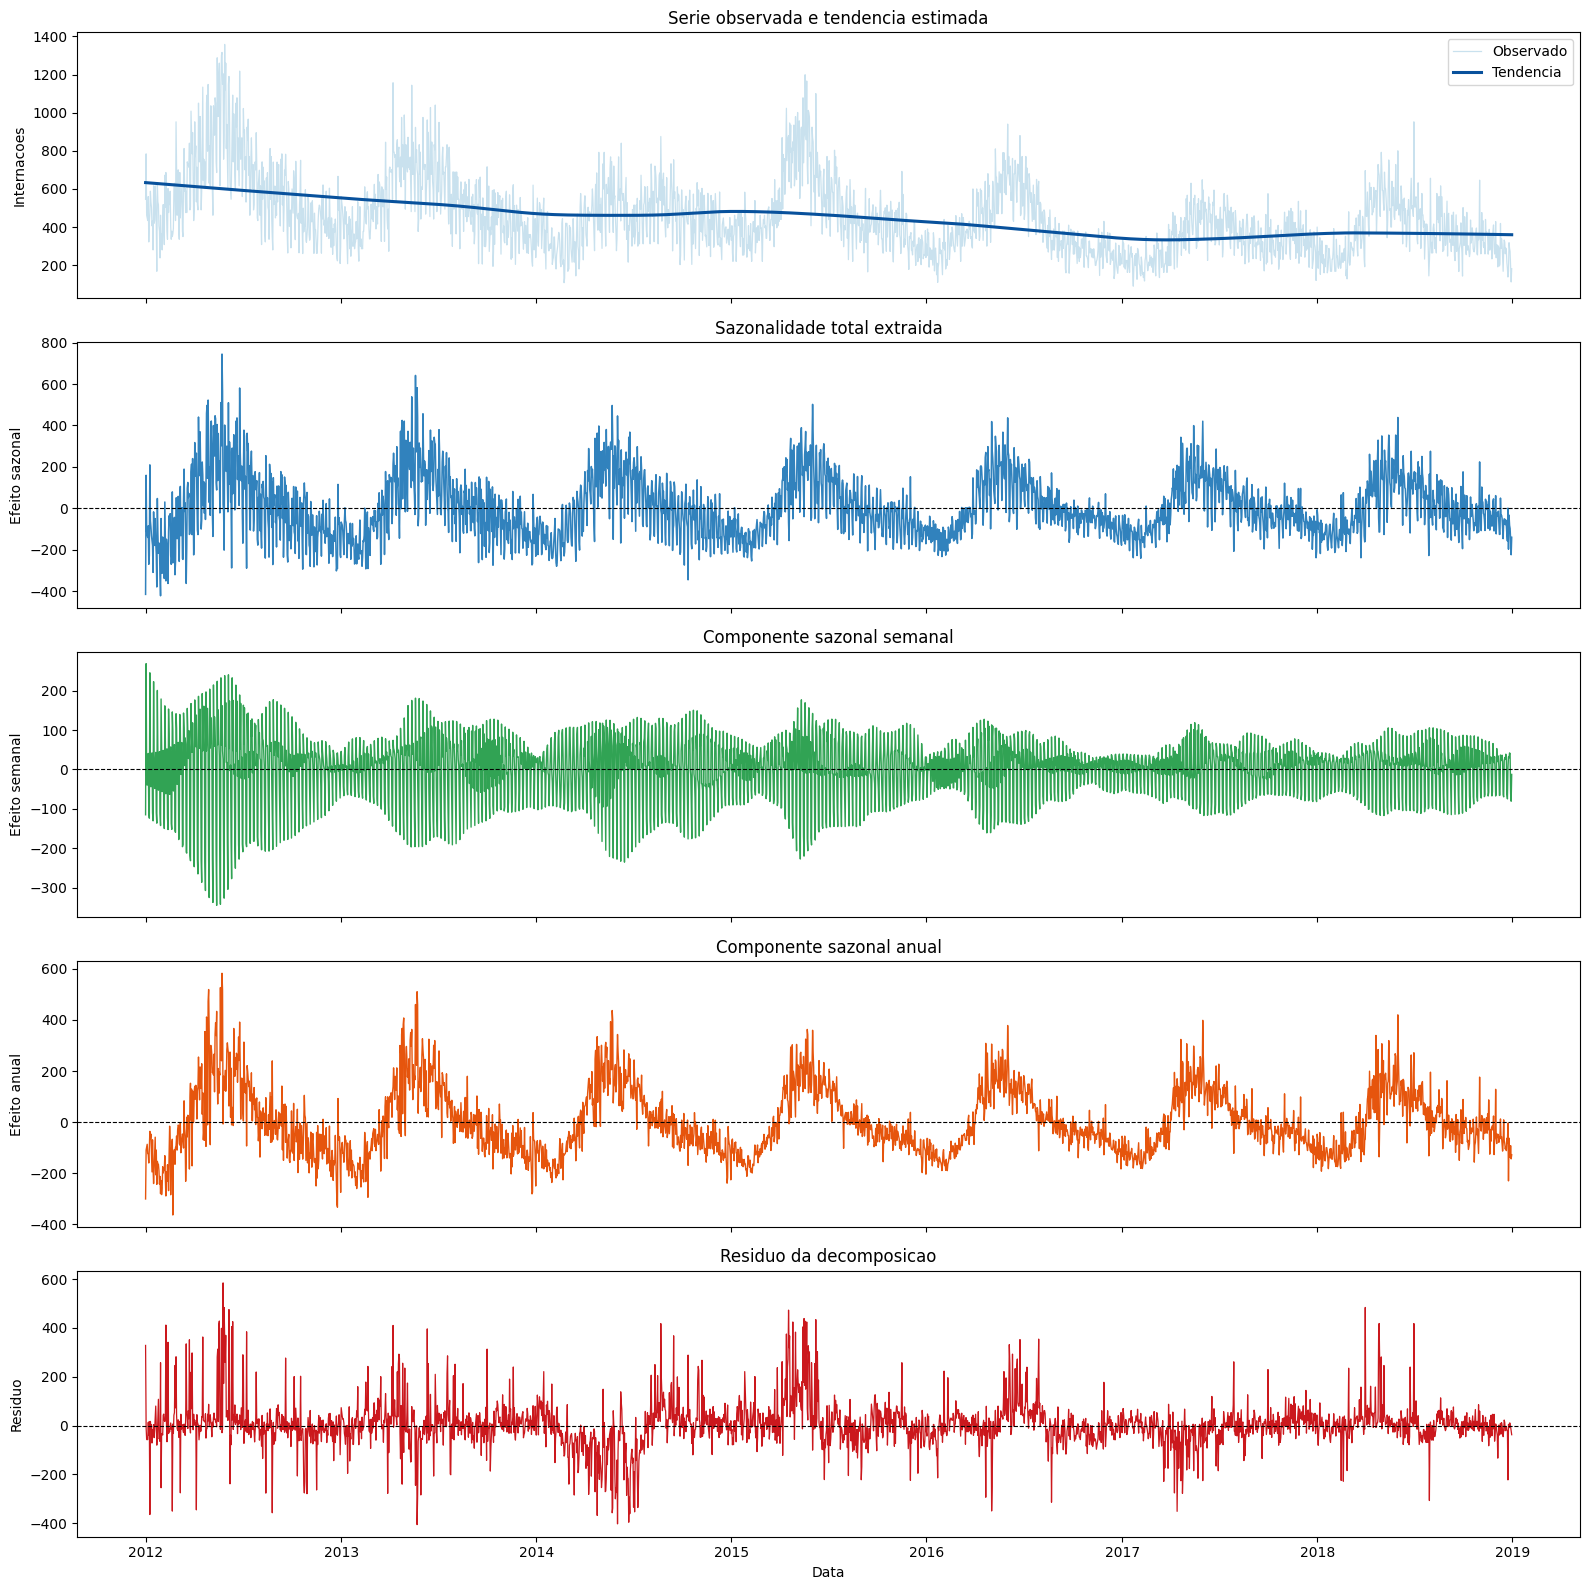

In [6]:
tem_sazonal_anual = df_decomp["sazonal_365"].notna().any()
n_linhas = 5 if tem_sazonal_anual else 4

fig, axes = plt.subplots(n_linhas, 1, figsize=(16, 3.2 * n_linhas), sharex=True)

axes[0].plot(df_decomp.index, df_decomp["observado"], color="#9ecae1", linewidth=0.9, alpha=0.55, label="Observado")
axes[0].plot(df_decomp.index, df_decomp["tendencia"], color="#08519c", linewidth=2.2, label="Tendencia")
axes[0].set_title("Serie observada e tendencia estimada")
axes[0].set_ylabel("Internacoes")
axes[0].legend(loc="upper right")

axes[1].plot(df_decomp.index, df_decomp["sazonal_total"], color="#3182bd", linewidth=1.1)
axes[1].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[1].set_title("Sazonalidade total extraida")
axes[1].set_ylabel("Efeito sazonal")

axes[2].plot(df_decomp.index, df_decomp["sazonal_7"], color="#31a354", linewidth=1.0)
axes[2].axhline(0, color="black", linestyle="--", linewidth=0.8)
axes[2].set_title("Componente sazonal semanal")
axes[2].set_ylabel("Efeito semanal")

if tem_sazonal_anual:
    axes[3].plot(df_decomp.index, df_decomp["sazonal_365"], color="#e6550d", linewidth=1.0)
    axes[3].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[3].set_title("Componente sazonal anual")
    axes[3].set_ylabel("Efeito anual")
    eixo_residuo = axes[4]
else:
    eixo_residuo = axes[3]

eixo_residuo.plot(df_decomp.index, df_decomp["residuo"], color="#cb181d", linewidth=0.9)
eixo_residuo.axhline(0, color="black", linestyle="--", linewidth=0.8)
eixo_residuo.set_title("Residuo da decomposicao")
eixo_residuo.set_ylabel("Residuo")
eixo_residuo.set_xlabel("Data")

plt.tight_layout()
plt.show()

### Resumo quantitativo da tendencia e dos componentes

Aqui resumimos numericamente o comportamento da tendencia e a intensidade relativa dos componentes. O uso do intervalo entre os percentis 5 e 95 ajuda a medir amplitude de forma menos sensivel a pontos extremos.

In [7]:
serie_tendencia_valida = df_decomp["tendencia"].dropna()
data_inicio_tendencia = serie_tendencia_valida.index.min()
data_fim_tendencia = serie_tendencia_valida.index.max()
tendencia_inicial = serie_tendencia_valida.iloc[0]
tendencia_final = serie_tendencia_valida.iloc[-1]
variacao_tendencia_abs = tendencia_final - tendencia_inicial
variacao_tendencia_pct = (tendencia_final / tendencia_inicial - 1) * 100 if tendencia_inicial != 0 else np.nan
data_pico_tendencia = serie_tendencia_valida.idxmax()
data_vale_tendencia = serie_tendencia_valida.idxmin()

colunas_componentes = ["tendencia", "sazonal_total", "sazonal_7", "residuo"]
if tem_sazonal_anual:
    colunas_componentes.insert(3, "sazonal_365")

resumo_componentes = pd.DataFrame(
    {
        "componente": colunas_componentes,
        "media": [df_decomp[col].mean() for col in colunas_componentes],
        "desvio_padrao": [df_decomp[col].std() for col in colunas_componentes],
        "amplitude_p5_p95": [df_decomp[col].quantile(0.95) - df_decomp[col].quantile(0.05) for col in colunas_componentes],
    }
)

perfil_tendencia_anual = (
    df_decomp.groupby("ano")["tendencia"]
    .mean()
    .reset_index()
)

display(resumo_componentes.round(2))
display(perfil_tendencia_anual.round(2))

print(f"Inicio da tendencia estimada: {data_inicio_tendencia.date()} -> {tendencia_inicial:.2f}")
print(f"Fim da tendencia estimada: {data_fim_tendencia.date()} -> {tendencia_final:.2f}")
print(f"Variacao absoluta da tendencia: {variacao_tendencia_abs:.2f}")
print(f"Variacao percentual da tendencia: {variacao_tendencia_pct:.2f}%")
print(f"Maior nivel de tendencia em: {data_pico_tendencia.date()} -> {serie_tendencia_valida.max():.2f}")
print(f"Menor nivel de tendencia em: {data_vale_tendencia.date()} -> {serie_tendencia_valida.min():.2f}")

,componente,media,desvio_padrao,amplitude_p5_p95
0,tendencia,447.20,84.18,267.44
1,sazonal_total,0.87,150.78,491.93
2,sazonal_7,-0.00,81.57,259.88
3,sazonal_365,0.87,129.02,410.60
4,residuo,4.19,97.52,303.00


,ano,tendencia
0,2012,592.37
1,2013,515.11
2,2014,466.96
3,2015,460.19
4,2016,385.97
5,2017,343.65
6,2018,365.93


Inicio da tendencia estimada: 2012-01-01 -> 633.13
Fim da tendencia estimada: 2018-12-31 -> 359.80
Variacao absoluta da tendencia: -273.33
Variacao percentual da tendencia: -43.17%
Maior nivel de tendencia em: 2012-01-01 -> 633.13
Menor nivel de tendencia em: 2017-03-25 -> 332.75


### Estabilidade do padrao sazonal

Agora usamos os componentes extraidos para verificar se o padrao semanal e anual permanece parecido ao longo do tempo. Isso e importante porque uma serie pode ter sazonalidade forte, mas instavel, o que muda bastante a estrategia de modelagem.

,dia_semana_nome,sazonal_7
0,Seg,77.89
1,Ter,39.22
2,Qua,56.33
3,Qui,18.18
4,Sex,14.24
5,Sab,-89.80
6,Dom,-115.97


,ano,amplitude_tendencia,amplitude_sazonal_semanal,volatilidade_residuo,amplitude_sazonal_anual
0,2012,72.67,401.10,121.33,524.29
1,2013,74.28,274.83,90.39,477.04
2,2014,19.58,280.86,118.18,425.95
3,2015,50.90,252.00,107.75,382.43
4,2016,79.70,223.39,81.19,353.05
5,2017,29.72,171.14,66.64,341.12
6,2018,8.67,191.13,70.93,337.47


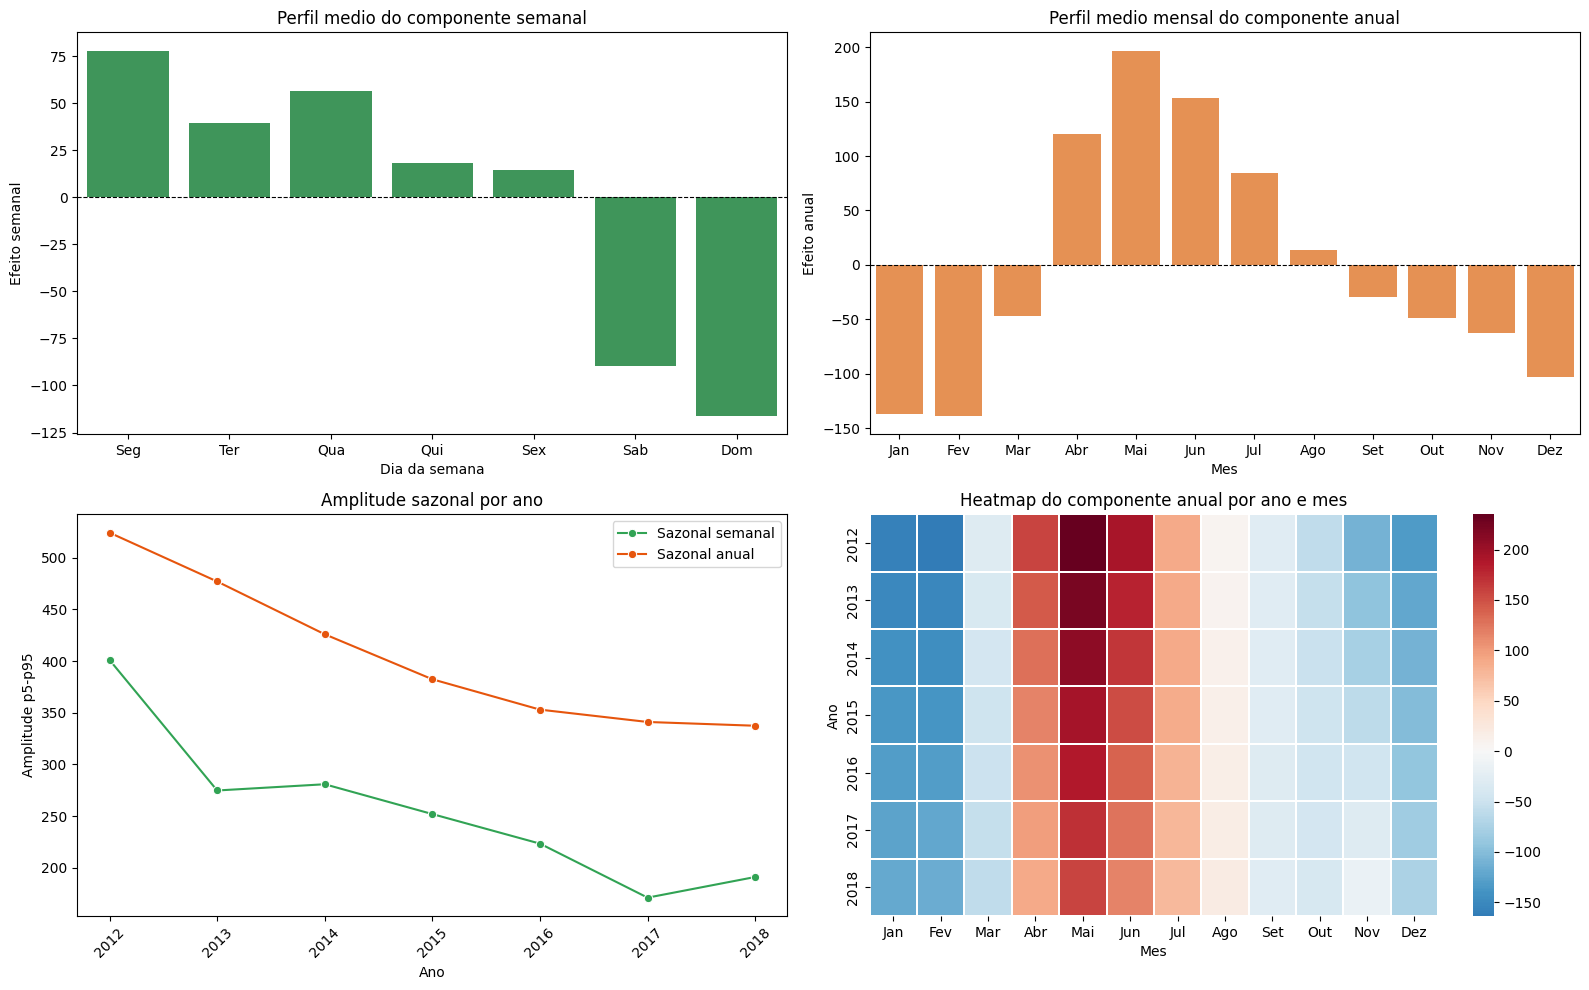

In [8]:
perfil_sazonal_semanal = (
    df_decomp.groupby(["dia_semana_num", "dia_semana_nome"], observed=True)["sazonal_7"]
    .mean()
    .reset_index()
    .sort_values("dia_semana_num")
)

amplitude_por_ano = (
    df_decomp.groupby("ano")
    .agg(
        amplitude_tendencia=("tendencia", lambda s: s.quantile(0.95) - s.quantile(0.05)),
        amplitude_sazonal_semanal=("sazonal_7", lambda s: s.quantile(0.95) - s.quantile(0.05)),
        volatilidade_residuo=("residuo", "std"),
    )
    .reset_index()
)

display(perfil_sazonal_semanal[["dia_semana_nome", "sazonal_7"]].round(2))

if tem_sazonal_anual:
    perfil_sazonal_anual_mensal = (
        df_decomp.groupby(["mes", "mes_nome"], observed=True)["sazonal_365"]
        .mean()
        .reset_index()
        .sort_values("mes")
    )

    amplitude_sazonal_anual = (
        df_decomp.groupby("ano")["sazonal_365"]
        .apply(lambda s: s.quantile(0.95) - s.quantile(0.05))
        .rename("amplitude_sazonal_anual")
        .reset_index()
    )

    amplitude_por_ano = amplitude_por_ano.merge(amplitude_sazonal_anual, on="ano", how="left")

    heatmap_sazonal_anual = (
        df_decomp.groupby(["ano", "mes_nome"], observed=True)["sazonal_365"]
        .mean()
        .reset_index()
        .pivot(index="ano", columns="mes_nome", values="sazonal_365")
        .reindex(columns=list(meses.values()))
    )

    display(amplitude_por_ano.round(2))

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    sns.barplot(data=perfil_sazonal_semanal, x="dia_semana_nome", y="sazonal_7", color="#31a354", ax=axes[0, 0])
    axes[0, 0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0, 0].set_title("Perfil medio do componente semanal")
    axes[0, 0].set_xlabel("Dia da semana")
    axes[0, 0].set_ylabel("Efeito semanal")

    sns.barplot(data=perfil_sazonal_anual_mensal, x="mes_nome", y="sazonal_365", color="#fd8d3c", ax=axes[0, 1])
    axes[0, 1].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0, 1].set_title("Perfil medio mensal do componente anual")
    axes[0, 1].set_xlabel("Mes")
    axes[0, 1].set_ylabel("Efeito anual")

    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_semanal", marker="o", color="#31a354", label="Sazonal semanal", ax=axes[1, 0])
    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_anual", marker="o", color="#e6550d", label="Sazonal anual", ax=axes[1, 0])
    axes[1, 0].set_title("Amplitude sazonal por ano")
    axes[1, 0].set_xlabel("Ano")
    axes[1, 0].set_ylabel("Amplitude p5-p95")
    axes[1, 0].tick_params(axis="x", rotation=45)

    sns.heatmap(heatmap_sazonal_anual, cmap="RdBu_r", center=0, linewidths=0.1, ax=axes[1, 1])
    axes[1, 1].set_title("Heatmap do componente anual por ano e mes")
    axes[1, 1].set_xlabel("Mes")
    axes[1, 1].set_ylabel("Ano")

    plt.tight_layout()
    plt.show()
else:
    display(amplitude_por_ano.round(2))

    fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

    sns.barplot(data=perfil_sazonal_semanal, x="dia_semana_nome", y="sazonal_7", color="#31a354", ax=axes[0])
    axes[0].axhline(0, color="black", linestyle="--", linewidth=0.8)
    axes[0].set_title("Perfil medio do componente semanal")
    axes[0].set_xlabel("Dia da semana")
    axes[0].set_ylabel("Efeito semanal")

    sns.lineplot(data=amplitude_por_ano, x="ano", y="amplitude_sazonal_semanal", marker="o", color="#31a354", ax=axes[1])
    axes[1].set_title("Amplitude semanal por ano")
    axes[1].set_xlabel("Ano")
    axes[1].set_ylabel("Amplitude p5-p95")
    axes[1].tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show()

### Resumo interpretativo dos resultados

A decomposicao por **MSTL** mostrou que a serie combina uma **queda estrutural de longo prazo** com **sazonalidades semanal e anual bem marcadas**. A tendencia estimada saiu de aproximadamente **633,1 internacoes** no inicio da serie, em **2012-01-01**, para **359,8** no fim, em **2018-12-31**, o que representa uma reducao de cerca de **43,2%**. Isso reforca que o nivel medio da serie mudou de forma importante ao longo do periodo e que a serie bruta esta longe de ser estacionaria em nivel.

Quando olhamos a tendencia media por ano, aparece uma trajetoria de queda clara entre **2012 (592,4)** e **2017 (343,7)**, com desaceleracao do recuo em **2014-2015** e uma **recomposicao moderada em 2018 (365,9)**. Esse desenho sugere que a serie nao e apenas sazonal: ela tambem sofreu mudancas estruturais importantes, com alguns periodos de estabilizacao ou reaceleracao dentro de uma tendencia geral de queda.

A componente semanal ficou bastante coerente com a analise de calendario. O efeito sazonal medio foi **positivo em segunda, terca e quarta**, com destaque para **segunda-feira (+77,9)** e **quarta-feira (+56,3)**, e **negativo no fim de semana**, principalmente **domingo (-116,0)** e **sabado (-89,8)**. Isso indica que parte importante do padrao observado na serie pode ser explicada por um ciclo semanal relativamente estavel, e nao apenas por variacao aleatoria.

A componente anual tambem confirmou um padrao sazonal forte. Pela decomposicao, a sazonalidade anual tem **amplitude p5-p95 de 410,6**, valor alto para uma componente recorrente. Isso sugere que o aumento da serie no outono e inicio do inverno nao e apenas um efeito da tendencia, mas um componente sazonal anual recorrente e bem definido.

Ao comparar a intensidade dos componentes, a **sazonalidade total** teve a maior amplitude estrutural (**491,9** no intervalo p5-p95), seguida pela **sazonalidade anual (410,6)**. A **tendencia** tambem permaneceu relevante (**267,4**), enquanto o **residuo** ainda ficou alto (**303,0**), o que e um sinal importante: mesmo com tendencia e sazonalidade explicitas, ainda existe variacao nao capturada pela decomposicao, possivelmente associada a eventos excepcionais, mudancas de notificacao ou quebras de regime.

As amplitudes sazonais tambem mudaram ao longo do tempo. Em **2012**, a amplitude semanal foi de **401,1** e a anual de **524,3**, enquanto em **2017** elas ficaram em **171,1** e **341,1** e, em **2018**, em **191,1** e **337,5**, respectivamente. Ou seja, a serie nao apenas perdeu nivel medio: ela tambem perdeu parte da intensidade sazonal ao longo do periodo, ainda que com alguma persistencia no final da serie. Alem disso, a **volatilidade do residuo** foi especialmente alta em **2012 (121,3)**, **2014 (118,2)** e **2015 (107,8)**, permanecendo menor, mas ainda relevante, em **2016 (81,2)** e **2018 (70,9)**. Isso reforca a suspeita de anos mais instaveis ou com eventos fora do padrao historico.

**Possiveis analises e consequencias**
- A queda estrutural da tendencia indica que a serie provavelmente nao e estacionaria no nivel e exige tratamento adicional antes de modelos estatisticos classicos.
- A sazonalidade semanal parece suficientemente clara para entrar como feature fixa, componente deterministico ou diferenca sazonal na modelagem.
- A amplitude alta da sazonalidade anual reforca a importancia de variaveis de tempo anual, clima e poluicao, especialmente entre outono e inverno.
- O residual ainda elevado sugere investigar anos e janelas anomalas, sobretudo os anos iniciais e os repiques intermediarios, antes de assumir um unico regime para toda a serie.
- Como tendencia e sazonalidade mudam de intensidade ao longo do tempo, vale testar abordagens robustas a mudanca de regime, validacao temporal por blocos e possivel segmentacao da serie por periodos.